# Итоговая домашняя работа: Trino + PostgreSQL + MySQL + Iceberg

**Автор:** Литвинов Никита Антонович, МИНДА 241

---

## Содержание

1. **Уровень 1: Подключения** — подключение к Trino, проверка каталогов PostgreSQL и MySQL
2. **Уровень 2: Агрегация данных** — SQL-запросы, работа с pandas DataFrame
3. **Уровень 3: Визуализация и Iceberg** — графики, сохранение данных в Iceberg

---

## Установка зависимостей

In [102]:
# Установка необходимых библиотек
%pip install trino pandas matplotlib seaborn plotly --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:
# Импорт библиотек
import trino
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Настройка отображения
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Цветовая палитра для графиков
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95C623']

---

# Уровень 1: Подключения

На этом уровне:
1. Подключимся к серверу Trino
2. Проверим доступность каталога PostgreSQL
3. Проверим доступность каталога MySQL

## 1.1 Подключение к Trino

In [104]:
# Параметры подключения к Trino
TRINO_HOST = 'localhost'
TRINO_PORT = 8085
TRINO_USER = 'admin'

def get_trino_connection(catalog='system'):
    """Создает подключение к Trino с указанным каталогом."""
    return trino.dbapi.connect(
        host=TRINO_HOST,
        port=TRINO_PORT,
        user=TRINO_USER,
        catalog=catalog
    )

def execute_query(query, catalog='system'):
    """Выполняет SQL-запрос и возвращает результат в виде DataFrame."""
    conn = get_trino_connection(catalog)
    cursor = conn.cursor()
    cursor.execute(query)
    columns = [desc[0] for desc in cursor.description]
    data = cursor.fetchall()
    return pd.DataFrame(data, columns=columns)

print('Функции подключения к Trino созданы')

Функции подключения к Trino созданы


In [105]:
# Проверка подключения - вывод списка каталогов
catalogs_df = execute_query('SHOW CATALOGS')
print('Доступные каталоги в Trino:')
catalogs_df

Доступные каталоги в Trino:


,Catalog
0,iceberg
1,mysql
2,postgresql
3,system


## 1.2 Проверка каталога PostgreSQL

In [106]:
# Список схем в PostgreSQL
pg_schemas = execute_query('SHOW SCHEMAS FROM postgresql')
print('Схемы в каталоге PostgreSQL:')
pg_schemas

Схемы в каталоге PostgreSQL:


,Schema
0,information_schema
1,pg_catalog
2,public


In [107]:
# Список таблиц в схеме public
pg_tables = execute_query('SHOW TABLES FROM postgresql.public')
print('Таблицы в схеме postgresql.public:')
pg_tables

Таблицы в схеме postgresql.public:


,Table
0,customers
1,orders


In [108]:
# Просмотр структуры таблицы customers
pg_customers_desc = execute_query('DESCRIBE postgresql.public.customers')
print('Структура таблицы customers:')
pg_customers_desc

Структура таблицы customers:


,Column,Type,Extra,Comment
0,customer_id,integer,,
1,customer_name,varchar(100),,
2,email,varchar(150),,
3,city,varchar(100),,
4,country,varchar(50),,
5,registration_date,date,,
6,segment,varchar(50),,


In [109]:
# Просмотр структуры таблицы orders
pg_orders_desc = execute_query('DESCRIBE postgresql.public.orders')
print('Структура таблицы orders:')
pg_orders_desc

Структура таблицы orders:


,Column,Type,Extra,Comment
0,order_id,integer,,
1,customer_id,integer,,
2,order_date,date,,
3,amount,"decimal(10,2)",,
4,status,varchar(20),,
5,payment_method,varchar(50),,
6,shipping_cost,"decimal(10,2)",,


In [110]:
# Примеры данных из PostgreSQL
print('Примеры данных из таблицы orders:')
execute_query('SELECT * FROM postgresql.public.orders LIMIT 5')

Примеры данных из таблицы orders:


,order_id,customer_id,order_date,amount,status,payment_method,shipping_cost
0,1,1,2024-01-05,15000.00,Completed,Card,500.00
1,2,2,2024-01-08,8500.50,Completed,Cash,350.00
2,3,3,2024-01-12,22000.00,Completed,Card,0.00
3,4,4,2024-01-15,5600.00,Completed,Transfer,250.00
4,5,5,2024-01-20,45000.00,Completed,Card,0.00


## 1.3 Проверка каталога MySQL

In [111]:
# Список схем в MySQL
mysql_schemas = execute_query('SHOW SCHEMAS FROM mysql')
print('Схемы в каталоге MySQL:')
mysql_schemas

Схемы в каталоге MySQL:


,Schema
0,information_schema
1,performance_schema
2,sales_db


In [112]:
# Список таблиц в схеме sales_db
mysql_tables = execute_query('SHOW TABLES FROM mysql.sales_db')
print('Таблицы в схеме mysql.sales_db:')
mysql_tables

Таблицы в схеме mysql.sales_db:


,Table
0,categories
1,products
2,sales


In [113]:
# Просмотр структуры таблицы products
mysql_products_desc = execute_query('DESCRIBE mysql.sales_db.products')
print('Структура таблицы products:')
mysql_products_desc

Структура таблицы products:


,Column,Type,Extra,Comment
0,product_id,integer,,
1,product_name,varchar(150),,
2,category_id,integer,,
3,price,"decimal(10,2)",,
4,stock_quantity,integer,,
5,supplier,varchar(100),,


In [114]:
# Просмотр структуры таблицы sales
mysql_sales_desc = execute_query('DESCRIBE mysql.sales_db.sales')
print('Структура таблицы sales:')
mysql_sales_desc

Структура таблицы sales:


,Column,Type,Extra,Comment
0,sale_id,integer,,
1,product_id,integer,,
2,sale_date,date,,
3,quantity,integer,,
4,unit_price,"decimal(10,2)",,
5,discount_percent,"decimal(5,2)",,
6,region,varchar(50),,


In [115]:
# Примеры данных из MySQL
print('Примеры данных из таблицы sales:')
execute_query('SELECT * FROM mysql.sales_db.sales LIMIT 5')

Примеры данных из таблицы sales:


,sale_id,product_id,sale_date,quantity,unit_price,discount_percent,region
0,1,1,2024-01-05,5,75000.00,0.00,Москва
1,2,3,2024-01-07,12,32000.00,5.00,Москва
2,3,6,2024-01-10,25,12000.00,10.00,Санкт-Петербург
3,4,8,2024-01-12,40,2500.00,0.00,Казань
4,5,17,2024-01-15,80,650.00,0.00,Новосибирск


### Итоги Уровня 1

Успешно выполнено:
- Подключение к серверу Trino
- Проверка каталога PostgreSQL: схемы `public`, таблицы `customers` и `orders`
- Проверка каталога MySQL: схема `sales_db`, таблицы `categories`, `products`, `sales`

---

# Уровень 2: Агрегация данных

На этом уровне:
1. Выполним агрегирующие SQL-запросы через Trino
2. Загрузим результаты в pandas DataFrame
3. Сформируем финальный агрегированный DataFrame

## 2.1 Агрегация данных из PostgreSQL

In [116]:
# Запрос 1: Ежемесячная статистика заказов
query_orders_monthly = '''
SELECT 
    date_trunc('month', order_date) AS month,
    COUNT(*) AS orders_count,
    SUM(amount) AS total_amount,
    AVG(amount) AS avg_amount,
    SUM(shipping_cost) AS total_shipping
FROM postgresql.public.orders
GROUP BY date_trunc('month', order_date)
ORDER BY month
'''

df_orders_monthly = execute_query(query_orders_monthly)
print('Ежемесячная статистика заказов (PostgreSQL):')
df_orders_monthly

Ежемесячная статистика заказов (PostgreSQL):


,month,orders_count,total_amount,avg_amount,total_shipping
0,2024-01-01,6,108100.50,18016.75,1500.00
1,2024-02-01,6,108500.00,18083.33,1380.00
2,2024-03-01,6,115000.00,19166.67,1100.00
3,2024-04-01,6,173400.00,28900.00,1420.00
4,2024-05-01,6,115300.00,19216.67,1000.00
5,2024-06-01,6,196300.00,32716.67,900.00
6,2024-07-01,3,41200.00,13733.33,770.00


In [117]:
# Запрос 2: Top-5 клиентов по сумме заказов
query_top_customers = '''
SELECT 
    c.customer_name,
    c.segment,
    c.city,
    COUNT(o.order_id) AS orders_count,
    SUM(o.amount) AS total_amount,
    AVG(o.amount) AS avg_order_amount
FROM postgresql.public.customers c
JOIN postgresql.public.orders o ON c.customer_id = o.customer_id
GROUP BY c.customer_name, c.segment, c.city
ORDER BY total_amount DESC
LIMIT 5
'''

df_top_customers = execute_query(query_top_customers)
print('Top-5 клиентов по сумме заказов:')
df_top_customers

Top-5 клиентов по сумме заказов:


,customer_name,segment,city,orders_count,total_amount,avg_order_amount
0,Морозов Алексей,VIP,Москва,3,155000.00,51666.67
1,Семенов Игорь,VIP,Челябинск,3,154000.00,51333.33
2,Федорова Светлана,VIP,Нижний Новгород,2,79000.00,39500.00
3,Иванов Петр,Premium,Москва,4,79000.00,19750.00
4,Козлов Дмитрий,Premium,Новосибирск,3,66000.00,22000.00


In [118]:
# Запрос 3: Статистика по сегментам клиентов
query_segments = '''
SELECT 
    c.segment,
    COUNT(DISTINCT c.customer_id) AS customers_count,
    COUNT(o.order_id) AS orders_count,
    SUM(o.amount) AS total_revenue,
    AVG(o.amount) AS avg_order_value
FROM postgresql.public.customers c
LEFT JOIN postgresql.public.orders o ON c.customer_id = o.customer_id
GROUP BY c.segment
ORDER BY total_revenue DESC
'''

df_segments = execute_query(query_segments)
print('Статистика по сегментам клиентов:')
df_segments

Статистика по сегментам клиентов:


,segment,customers_count,orders_count,total_revenue,avg_order_value
0,VIP,3,8,388000.00,48500.00
1,Premium,6,17,344400.00,20258.82
2,Standard,6,14,125400.50,8957.18


## 2.2 Агрегация данных из MySQL

In [119]:
# Запрос 4: Ежемесячные продажи по категориям
query_sales_category = '''
SELECT 
    date_trunc('month', s.sale_date) AS month,
    c.category_name,
    SUM(s.quantity) AS total_quantity,
    SUM(s.quantity * s.unit_price * (1 - s.discount_percent/100)) AS revenue
FROM mysql.sales_db.sales s
JOIN mysql.sales_db.products p ON s.product_id = p.product_id
JOIN mysql.sales_db.categories c ON p.category_id = c.category_id
GROUP BY date_trunc('month', s.sale_date), c.category_name
ORDER BY month, revenue DESC
'''

df_sales_category = execute_query(query_sales_category)
print('Ежемесячные продажи по категориям (MySQL):')
df_sales_category

Ежемесячные продажи по категориям (MySQL):


,month,category_name,total_quantity,revenue
0,2024-01-01,Электроника,20,934800.0000
1,2024-01-01,Одежда,80,595000.0000
2,2024-01-01,Косметика,30,91200.0000
3,2024-01-01,Книги,80,52000.0000
4,2024-02-01,Электроника,12,802000.0000
5,2024-02-01,Бытовая техника,5,239600.0000
6,2024-02-01,Одежда,55,210375.0000
7,2024-02-01,Спорт,10,180000.0000
8,2024-02-01,Косметика,60,85500.0000
9,2024-02-01,Книги,45,81000.0000


In [120]:
# Запрос 5: Top-10 продуктов по выручке
query_top_products = '''
SELECT 
    p.product_name,
    c.category_name,
    SUM(s.quantity) AS total_sold,
    SUM(s.quantity * s.unit_price * (1 - s.discount_percent/100)) AS total_revenue,
    AVG(s.discount_percent) AS avg_discount
FROM mysql.sales_db.sales s
JOIN mysql.sales_db.products p ON s.product_id = p.product_id
JOIN mysql.sales_db.categories c ON p.category_id = c.category_id
GROUP BY p.product_name, c.category_name
ORDER BY total_revenue DESC
LIMIT 10
'''

df_top_products = execute_query(query_top_products)
print('Top-10 продуктов по выручке:')
df_top_products

Top-10 продуктов по выручке:


,product_name,category_name,total_sold,total_revenue,avg_discount
0,Смартфон Galaxy S24,Электроника,40,2880000.0000,3.75
1,Наушники Sony WH-1000XM5,Электроника,55,1643200.0000,6.67
2,Умные часы Apple Watch,Электроника,25,1018500.0000,2.50
3,Куртка зимняя,Одежда,95,960000.0000,15.00
4,Планшет iPad Air,Электроника,11,638000.0000,0.00
5,Велосипед горный,Спорт,13,573750.0000,2.50
6,Ноутбук ASUS VivoBook,Электроника,9,565500.0000,2.50
7,Кроссовки Nike Air Max,Одежда,35,510000.0000,2.50
8,Джинсы классические,Одежда,125,493875.0000,12.50
9,Гантели наборные,Спорт,28,471600.0000,5.00


In [121]:
# Запрос 6: Продажи по регионам
query_regions = '''
SELECT 
    s.region,
    COUNT(*) AS transactions,
    SUM(s.quantity) AS total_quantity,
    SUM(s.quantity * s.unit_price * (1 - s.discount_percent/100)) AS revenue
FROM mysql.sales_db.sales s
GROUP BY s.region
ORDER BY revenue DESC
'''

df_regions = execute_query(query_regions)
print('Продажи по регионам:')
df_regions

Продажи по регионам:


,region,transactions,total_quantity,revenue
0,Москва,15,251,5344250.0000
1,Санкт-Петербург,7,136,2082000.0000
2,Казань,6,107,1684600.0000
3,Самара,5,115,1033050.0000
4,Екатеринбург,4,120,836000.0000
5,Ростов,3,190,656375.0000
6,Новосибирск,4,248,602200.0000


## 2.3 Cross-Database анализ (PostgreSQL + MySQL)

In [122]:
# Запрос 7: Сравнение ежемесячной выручки PostgreSQL vs MySQL
query_cross_db = '''
WITH pg_monthly AS (
    SELECT 
        date_trunc('month', order_date) AS month,
        'PostgreSQL Orders' AS source,
        SUM(amount) AS revenue
    FROM postgresql.public.orders
    GROUP BY date_trunc('month', order_date)
),
mysql_monthly AS (
    SELECT 
        date_trunc('month', sale_date) AS month,
        'MySQL Sales' AS source,
        SUM(quantity * unit_price * (1 - discount_percent/100)) AS revenue
    FROM mysql.sales_db.sales
    GROUP BY date_trunc('month', sale_date)
)
SELECT * FROM pg_monthly
UNION ALL
SELECT * FROM mysql_monthly
ORDER BY month, source
'''

df_cross_db = execute_query(query_cross_db)
print('Сравнение выручки PostgreSQL vs MySQL:')
df_cross_db

Сравнение выручки PostgreSQL vs MySQL:


,month,source,revenue
0,2024-01-01,MySQL Sales,1673000.0000
1,2024-01-01,PostgreSQL Orders,108100.5000
2,2024-02-01,MySQL Sales,1598475.0000
3,2024-02-01,PostgreSQL Orders,108500.0000
4,2024-03-01,MySQL Sales,1820650.0000
5,2024-03-01,PostgreSQL Orders,115000.0000
6,2024-04-01,MySQL Sales,2012200.0000
7,2024-04-01,PostgreSQL Orders,173400.0000
8,2024-05-01,MySQL Sales,2082600.0000
9,2024-05-01,PostgreSQL Orders,115300.0000


## 2.4 Формирование финального DataFrame

In [123]:
# Финальный агрегированный DataFrame для сохранения в Iceberg
# Объединяем данные из обоих источников по месяцам

query_final = '''
WITH pg_stats AS (
    SELECT 
        date_trunc('month', o.order_date) AS month,
        COUNT(DISTINCT o.order_id) AS pg_orders_count,
        SUM(o.amount) AS pg_orders_revenue,
        COUNT(DISTINCT o.customer_id) AS pg_unique_customers
    FROM postgresql.public.orders o
    GROUP BY date_trunc('month', o.order_date)
),
mysql_stats AS (
    SELECT 
        date_trunc('month', s.sale_date) AS month,
        COUNT(*) AS mysql_transactions,
        SUM(s.quantity) AS mysql_items_sold,
        SUM(s.quantity * s.unit_price * (1 - s.discount_percent/100)) AS mysql_sales_revenue
    FROM mysql.sales_db.sales s
    GROUP BY date_trunc('month', s.sale_date)
)
SELECT 
    COALESCE(pg.month, ms.month) AS report_month,
    COALESCE(pg.pg_orders_count, 0) AS orders_count,
    COALESCE(pg.pg_orders_revenue, 0) AS orders_revenue,
    COALESCE(pg.pg_unique_customers, 0) AS unique_customers,
    COALESCE(ms.mysql_transactions, 0) AS sales_transactions,
    COALESCE(ms.mysql_items_sold, 0) AS items_sold,
    COALESCE(ms.mysql_sales_revenue, 0) AS sales_revenue,
    COALESCE(pg.pg_orders_revenue, 0) + COALESCE(ms.mysql_sales_revenue, 0) AS total_revenue
FROM pg_stats pg
FULL OUTER JOIN mysql_stats ms ON pg.month = ms.month
ORDER BY report_month
'''

df_final = execute_query(query_final)
print('Финальный агрегированный DataFrame:')
df_final

Финальный агрегированный DataFrame:


,report_month,orders_count,orders_revenue,unique_customers,sales_transactions,items_sold,sales_revenue,total_revenue
0,2024-01-01,6,108100.50,5,8,210,1673000.0000,1781100.5000
1,2024-02-01,6,108500.00,6,8,187,1598475.0000,1706975.0000
2,2024-03-01,6,115000.00,6,7,118,1820650.0000,1935650.0000
3,2024-04-01,6,173400.00,6,7,270,2012200.0000,2185600.0000
4,2024-05-01,6,115300.00,6,7,144,2082600.0000,2197900.0000
5,2024-06-01,6,196300.00,6,7,238,3051550.0000,3247850.0000
6,2024-07-01,3,41200.00,3,0,0,0.0000,41200.0000


In [124]:
# Статистика финального DataFrame
print('Статистика финального DataFrame:')
print(f'Количество записей: {len(df_final)}')
print(f'Период: {df_final["report_month"].min()} — {df_final["report_month"].max()}')
print(f'Общая выручка: {df_final["total_revenue"].sum():,.2f} руб.')
print(f'Всего заказов: {df_final["orders_count"].sum()}')
print(f'Всего транзакций продаж: {df_final["sales_transactions"].sum()}')

Статистика финального DataFrame:
Количество записей: 7
Период: 2024-01-01 — 2024-07-01
Общая выручка: 13,096,275.50 руб.
Всего заказов: 39
Всего транзакций продаж: 44


### Итоги Уровня 2

Выполнено:
- 7 агрегирующих SQL-запросов через Trino
- Анализ данных из PostgreSQL (заказы, клиенты, сегменты)
- Анализ данных из MySQL (продажи, продукты, категории, регионы)
- Cross-database анализ (сравнение двух источников)
- Сформирован финальный агрегированный DataFrame

---

# Уровень 3: Визуализация и Iceberg

На этом уровне:
1. Построим графики на основе агрегированных данных
2. Создадим схему и таблицу в Iceberg
3. Сохраним данные и проверим результат

## 3.1 Визуализация данных

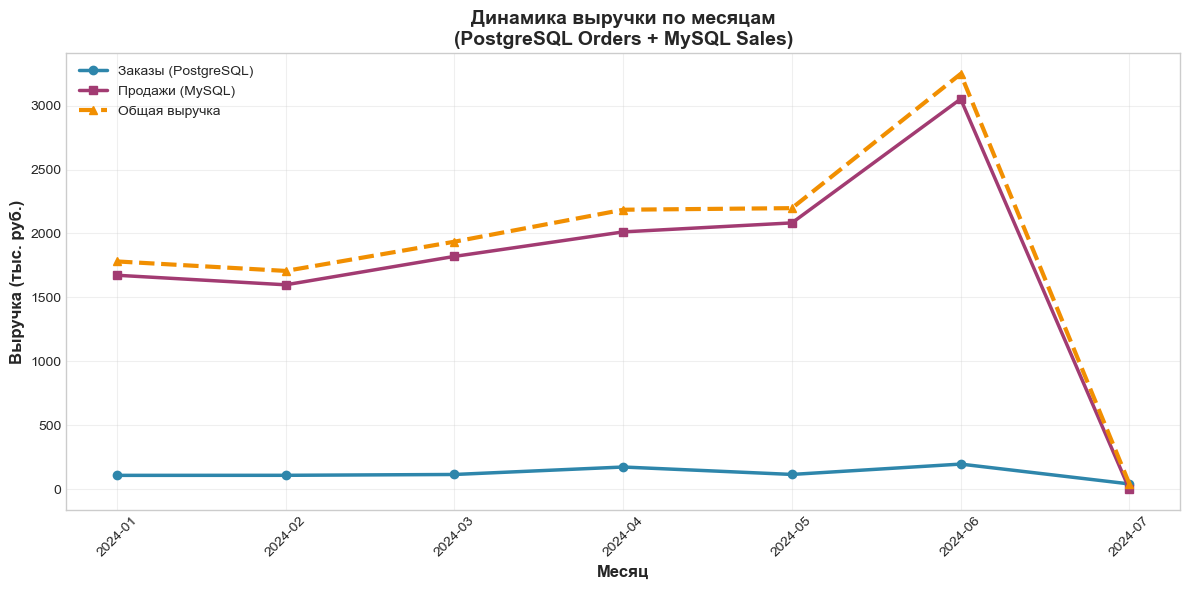

In [125]:
# График 1: Динамика выручки по месяцам (линейный график)
fig, ax = plt.subplots(figsize=(12, 6))

df_plot = df_final.copy()
df_plot['month_str'] = pd.to_datetime(df_plot['report_month']).dt.strftime('%Y-%m')

ax.plot(df_plot['month_str'], df_plot['orders_revenue']/1000, 
        marker='o', linewidth=2.5, label='Заказы (PostgreSQL)', color=COLORS[0])
ax.plot(df_plot['month_str'], df_plot['sales_revenue']/1000, 
        marker='s', linewidth=2.5, label='Продажи (MySQL)', color=COLORS[1])
ax.plot(df_plot['month_str'], df_plot['total_revenue']/1000, 
        marker='^', linewidth=3, label='Общая выручка', color=COLORS[2], linestyle='--')

ax.set_xlabel('Месяц', fontsize=12, fontweight='bold')
ax.set_ylabel('Выручка (тыс. руб.)', fontsize=12, fontweight='bold')
ax.set_title('Динамика выручки по месяцам\n(PostgreSQL Orders + MySQL Sales)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

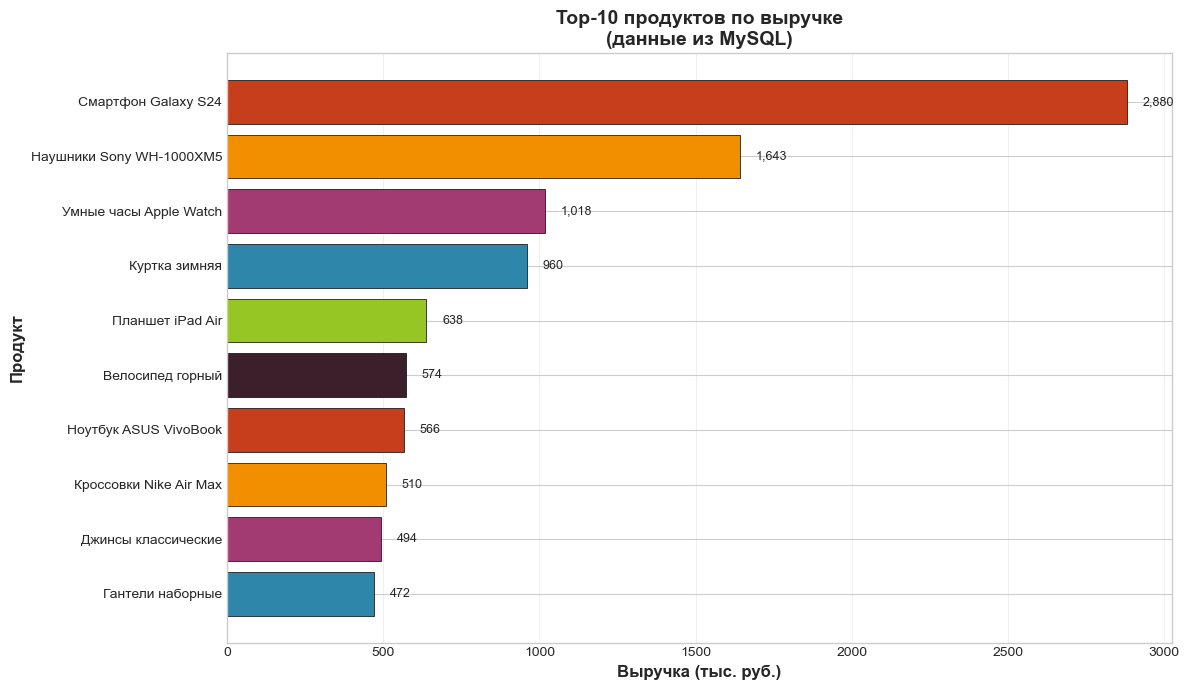

In [126]:
# График 2: Top-10 продуктов по выручке (горизонтальная столбчатая диаграмма)
fig, ax = plt.subplots(figsize=(12, 7))

df_top_products_sorted = df_top_products.sort_values('total_revenue', ascending=True)

colors_cat = [COLORS[i % len(COLORS)] for i in range(len(df_top_products_sorted))]
bars = ax.barh(df_top_products_sorted['product_name'], 
               df_top_products_sorted['total_revenue']/1000, 
               color=colors_cat, edgecolor='black', linewidth=0.5)

# Добавляем значения на столбцы
for bar, val in zip(bars, df_top_products_sorted['total_revenue']/1000):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, 
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Выручка (тыс. руб.)', fontsize=12, fontweight='bold')
ax.set_ylabel('Продукт', fontsize=12, fontweight='bold')
ax.set_title('Top-10 продуктов по выручке\n(данные из MySQL)', 
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

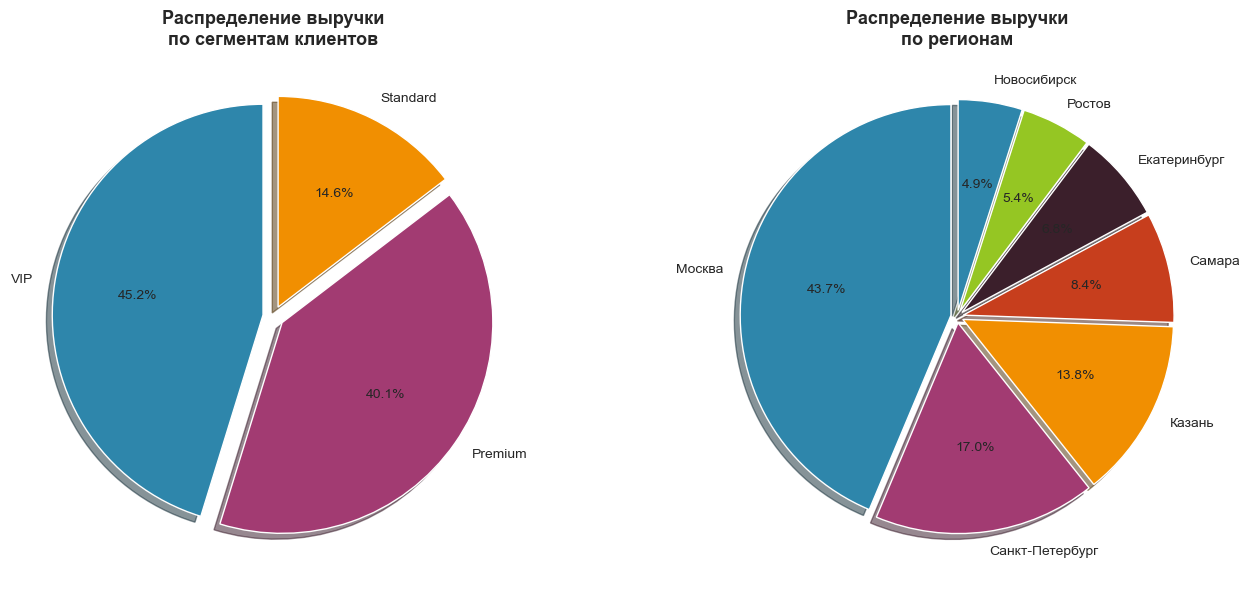

In [127]:
# График 3: Распределение выручки по сегментам клиентов (pie chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart сегментов
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    df_segments['total_revenue'], 
    labels=df_segments['segment'],
    autopct='%1.1f%%',
    colors=COLORS[:len(df_segments)],
    explode=[0.05] * len(df_segments),
    shadow=True,
    startangle=90
)
ax1.set_title('Распределение выручки\nпо сегментам клиентов', 
              fontsize=13, fontweight='bold')

# Pie chart регионов
ax2 = axes[1]
wedges2, texts2, autotexts2 = ax2.pie(
    df_regions['revenue'], 
    labels=df_regions['region'],
    autopct='%1.1f%%',
    colors=COLORS[:len(df_regions)],
    explode=[0.03] * len(df_regions),
    shadow=True,
    startangle=90
)
ax2.set_title('Распределение выручки\nпо регионам', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

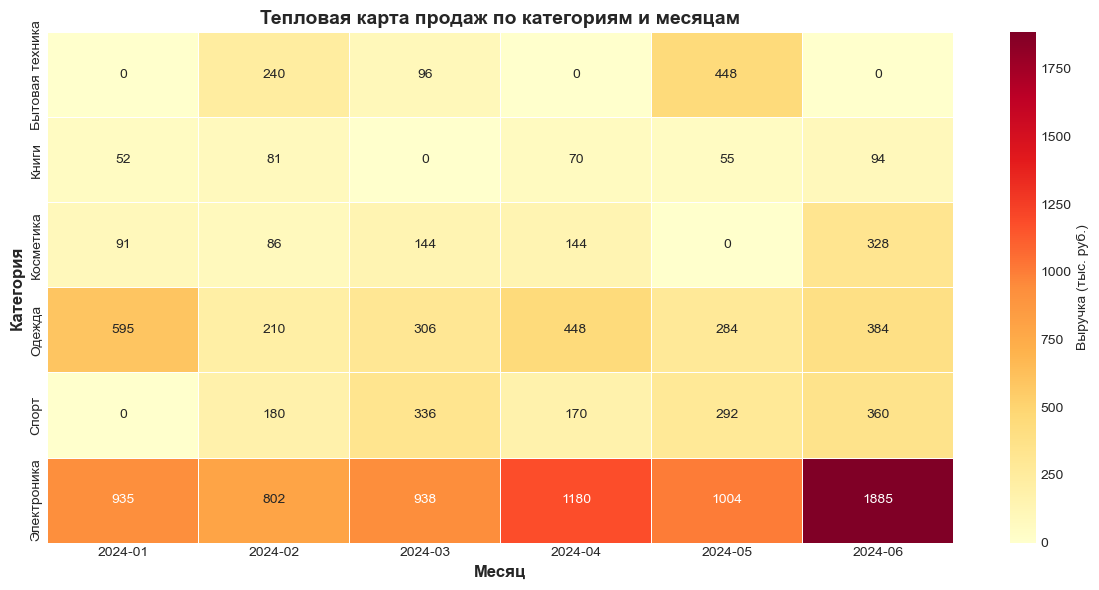

In [128]:
# График 4: Heatmap продаж по категориям и месяцам
fig, ax = plt.subplots(figsize=(12, 6))

# Подготовка данных для heatmap
df_heatmap = df_sales_category.copy()
df_heatmap['month_str'] = pd.to_datetime(df_heatmap['month']).dt.strftime('%Y-%m')
pivot_table = df_heatmap.pivot_table(
    values='revenue', 
    index='category_name', 
    columns='month_str', 
    aggfunc='sum',
    fill_value=0
).astype(float)

sns.heatmap(pivot_table/1000, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Выручка (тыс. руб.)'})

ax.set_xlabel('Месяц', fontsize=12, fontweight='bold')
ax.set_ylabel('Категория', fontsize=12, fontweight='bold')
ax.set_title('Тепловая карта продаж по категориям и месяцам', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.2 Сохранение данных в Iceberg

In [129]:
# Создание схемы в Iceberg (если не существует)
conn = get_trino_connection('iceberg')
cursor = conn.cursor()

create_schema_sql = '''
CREATE SCHEMA IF NOT EXISTS iceberg.analytics
WITH (location = 's3a://warehouse/analytics/')
'''

cursor.execute(create_schema_sql)
print('Схема iceberg.analytics создана (или уже существует)')

Схема iceberg.analytics создана (или уже существует)


In [130]:
# Проверка созданной схемы
iceberg_schemas = execute_query('SHOW SCHEMAS FROM iceberg')
print('Схемы в каталоге Iceberg:')
iceberg_schemas

Схемы в каталоге Iceberg:


,Schema
0,analytics
1,information_schema


In [131]:
# Удаление таблицы если существует (для повторного запуска)
conn = get_trino_connection('iceberg')
cursor = conn.cursor()

try:
    cursor.execute('DROP TABLE IF EXISTS iceberg.analytics.monthly_report')
    print('Старая таблица удалена (если существовала)')
except Exception as e:
    print(f'Примечание: {e}')

Старая таблица удалена (если существовала)


In [132]:
# Создание Iceberg таблицы с партиционированием по месяцам
create_table_sql = '''
CREATE TABLE iceberg.analytics.monthly_report (
    report_month DATE,
    orders_count INTEGER,
    orders_revenue DECIMAL(15, 2),
    unique_customers INTEGER,
    sales_transactions INTEGER,
    items_sold INTEGER,
    sales_revenue DECIMAL(15, 2),
    total_revenue DECIMAL(15, 2)
)
WITH (
    format = 'PARQUET',
    partitioning = ARRAY['month(report_month)']
)
'''

conn = get_trino_connection('iceberg')
cursor = conn.cursor()
cursor.execute(create_table_sql)
print('Таблица iceberg.analytics.monthly_report создана с партиционированием по месяцам')

Таблица iceberg.analytics.monthly_report создана с партиционированием по месяцам


In [133]:
# Сохранение агрегированных данных в Iceberg
insert_sql = '''
INSERT INTO iceberg.analytics.monthly_report
WITH pg_stats AS (
    SELECT 
        CAST(date_trunc('month', o.order_date) AS DATE) AS month,
        COUNT(DISTINCT o.order_id) AS pg_orders_count,
        SUM(o.amount) AS pg_orders_revenue,
        COUNT(DISTINCT o.customer_id) AS pg_unique_customers
    FROM postgresql.public.orders o
    GROUP BY CAST(date_trunc('month', o.order_date) AS DATE)
),
mysql_stats AS (
    SELECT 
        CAST(date_trunc('month', s.sale_date) AS DATE) AS month,
        COUNT(*) AS mysql_transactions,
        SUM(s.quantity) AS mysql_items_sold,
        SUM(s.quantity * s.unit_price * (1 - s.discount_percent/100)) AS mysql_sales_revenue
    FROM mysql.sales_db.sales s
    GROUP BY CAST(date_trunc('month', s.sale_date) AS DATE)
)
SELECT 
    COALESCE(pg.month, ms.month) AS report_month,
    CAST(COALESCE(pg.pg_orders_count, 0) AS INTEGER) AS orders_count,
    CAST(COALESCE(pg.pg_orders_revenue, 0) AS DECIMAL(15,2)) AS orders_revenue,
    CAST(COALESCE(pg.pg_unique_customers, 0) AS INTEGER) AS unique_customers,
    CAST(COALESCE(ms.mysql_transactions, 0) AS INTEGER) AS sales_transactions,
    CAST(COALESCE(ms.mysql_items_sold, 0) AS INTEGER) AS items_sold,
    CAST(COALESCE(ms.mysql_sales_revenue, 0) AS DECIMAL(15,2)) AS sales_revenue,
    CAST(COALESCE(pg.pg_orders_revenue, 0) + COALESCE(ms.mysql_sales_revenue, 0) AS DECIMAL(15,2)) AS total_revenue
FROM pg_stats pg
FULL OUTER JOIN mysql_stats ms ON pg.month = ms.month
'''

conn = get_trino_connection('iceberg')
cursor = conn.cursor()
cursor.execute(insert_sql)
print('Данные успешно сохранены в iceberg.analytics.monthly_report')

Данные успешно сохранены в iceberg.analytics.monthly_report


In [134]:
# Проверочный SQL-запрос к Iceberg таблице
verify_df = execute_query('SELECT * FROM iceberg.analytics.monthly_report ORDER BY report_month')
print('Проверка данных в Iceberg таблице:')
verify_df

Проверка данных в Iceberg таблице:


,report_month,orders_count,orders_revenue,unique_customers,sales_transactions,items_sold,sales_revenue,total_revenue
0,2024-01-01,6,108100.50,5,8,210,1673000.00,1781100.50
1,2024-02-01,6,108500.00,6,8,187,1598475.00,1706975.00
2,2024-03-01,6,115000.00,6,7,118,1820650.00,1935650.00
3,2024-04-01,6,173400.00,6,7,270,2012200.00,2185600.00
4,2024-05-01,6,115300.00,6,7,144,2082600.00,2197900.00
5,2024-06-01,6,196300.00,6,7,238,3051550.00,3247850.00
6,2024-07-01,3,41200.00,3,0,0,0.00,41200.00


In [135]:
# Проверка метаданных таблицы
table_info = execute_query('DESCRIBE iceberg.analytics.monthly_report')
print('Структура таблицы в Iceberg:')
table_info

Структура таблицы в Iceberg:


,Column,Type,Extra,Comment
0,report_month,date,,
1,orders_count,integer,,
2,orders_revenue,"decimal(15,2)",,
3,unique_customers,integer,,
4,sales_transactions,integer,,
5,items_sold,integer,,
6,sales_revenue,"decimal(15,2)",,
7,total_revenue,"decimal(15,2)",,


## 3.3 Дополнительно: работа со снапшотами Iceberg

In [136]:
# Просмотр истории снапшотов (версий) таблицы
snapshots_query = '''
SELECT 
    snapshot_id,
    parent_id,
    operation,
    manifest_list,
    committed_at
FROM iceberg.analytics."monthly_report$snapshots"
ORDER BY committed_at DESC
'''

try:
    snapshots_df = execute_query(snapshots_query)
    print('История снапшотов Iceberg таблицы:')
    display(snapshots_df)
except Exception as e:
    print(f'Примечание: Снапшоты недоступны ({e})')

История снапшотов Iceberg таблицы:


,snapshot_id,parent_id,operation,manifest_list,committed_at
0,7852934723404305345,9.182408e+18,append,s3a://warehouse/analytics/monthly_report-fe752...,2026-01-09 01:14:13.317000+07:00
1,9182408136780740656,NaN,append,s3a://warehouse/analytics/monthly_report-fe752...,2026-01-09 01:14:13.121000+07:00


In [137]:
# Просмотр партиций таблицы
partitions_query = '''
SELECT 
    partition,
    record_count,
    file_count
FROM iceberg.analytics."monthly_report$partitions"
'''

try:
    partitions_df = execute_query(partitions_query)
    print('Партиции Iceberg таблицы:')
    display(partitions_df)
except Exception as e:
    print(f'Примечание: Информация о партициях недоступна ({e})')

Партиции Iceberg таблицы:


,partition,record_count,file_count
0,(report_month_month: 653),1,1
1,(report_month_month: 654),1,1
2,(report_month_month: 648),1,1
3,(report_month_month: 651),1,1
4,(report_month_month: 652),1,1
5,(report_month_month: 649),1,1
6,(report_month_month: 650),1,1


In [138]:
# Агрегирующий запрос к Iceberg для проверки
agg_query = '''
SELECT 
    COUNT(*) AS total_months,
    SUM(orders_count) AS total_orders,
    SUM(sales_transactions) AS total_sales,
    SUM(total_revenue) AS grand_total_revenue,
    AVG(total_revenue) AS avg_monthly_revenue
FROM iceberg.analytics.monthly_report
'''

agg_df = execute_query(agg_query)
print('Сводная статистика из Iceberg:')
agg_df

Сводная статистика из Iceberg:


,total_months,total_orders,total_sales,grand_total_revenue,avg_monthly_revenue
0,7,39,44,13096275.50,1870896.50


### Итоги Уровня 3

Выполнено:
- Построено 4 графика с оформлением (подписи осей, заголовки, легенды):
  - Линейный график динамики выручки
  - Столбчатая диаграмма Top-10 продуктов
  - Круговые диаграммы распределения по сегментам и регионам
  - Тепловая карта продаж по категориям
- Создана схема `iceberg.analytics` в каталоге Iceberg
- Создана таблица `monthly_report` с партиционированием по месяцам
- Данные сохранены в Iceberg
- Выполнены проверочные запросы